In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="red">ch11. 데이터프레임과 시리즈(Pandas)</font>
# 9절. 데이터 그룹화 및 집계

In [8]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.iloc[[0,49,50,99,100,149]]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
99,5.7,2.8,4.1,1.3,versicolor
100,6.3,3.3,6.0,2.5,virginica
149,5.9,3.0,5.1,1.8,virginica


## 9.1 Group by
    cf. pivot_table

In [17]:
iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [22]:
# 1) 그룹화 방법 1
#    df.groupby(by=[그룹핑할열이름])[함수적용해서출력할열들].기초통계함수()
    # [함수적용해서출력할열들] 생략시 모든 열이 적용
iris_grouped = iris.groupby('Species')
iris_grouped = iris.groupby(iris.Species)
iris_grouped_sum = iris_grouped.sum()
iris_grouped_sum   # iris.groupby('Species').sum()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [24]:
# setosa, virginica의 집계만
iris_grouped_sum.loc[['setosa','virginica']]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,,,,
setosa,250.3,171.4,73.1,12.3
virginica,329.4,148.7,277.6,101.3


In [25]:
print(iris_grouped_sum.index)

Index(['setosa', 'versicolor', 'virginica'], dtype='object', name='Species')


In [28]:
iris_grouped_sum.reset_index(inplace=True) #인덱스를 컬럼으로 편입시킴

In [29]:
iris_grouped_sum

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [31]:
# setosa, virginica의 집계만
iris_grouped_sum[(iris_grouped_sum.Species=='setosa') | (iris_grouped_sum.Species=='virginica')]
iris_grouped_sum[iris_grouped_sum.Species.isin(['setosa', 'virginica'])]

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
2,virginica,329.4,148.7,277.6,101.3


In [34]:
# 1) 그룹화 방법 1-1 : 그룹핑할 때 index를 컬럼 데이터로 편입(reset_index()가 필요X)
#    df.groupby(by=[그룹핑할열이름], as_index=False)[함수적용해서출력할열들].기초통계함수()
    # [함수적용해서출력할열들] 생략시 모든 열이 적용
iris.groupby(iris['Species'], as_index=False).sum()
iris.groupby(iris.Species, as_index=False).sum()
iris.groupby('Species', as_index=False).sum()

,Species,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,setosa,250.3,171.4,73.1,12.3
1,versicolor,296.8,138.5,213.0,66.3
2,virginica,329.4,148.7,277.6,101.3


In [38]:
# 종별 Sepal.Length와 Sepal.Width의 평균
iris.groupby('Species').mean()[['Sepal.Length','Sepal.Width']]
iris.groupby('Species')[['Sepal.Length','Sepal.Width']].mean()

,Sepal.Length,Sepal.Width
Species,,
setosa,5.006,3.428
versicolor,5.936,2.770
virginica,6.588,2.974


In [43]:
# 종별 Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length'].sum() # 결과가 시리즈(1차원)

Species
setosa        250.3
versicolor    296.8
virginica     329.4
Name: Sepal.Length, dtype: float64

In [40]:
# 종별 Sepal.Length의 합계
iris.groupby('Species')['Sepal.Length',].sum()
iris.groupby('Species')[['Sepal.Length']].sum() # 결과가 데이터프레임(2차원)

,Sepal.Length
Species,
setosa,250.3
versicolor,296.8
virginica,329.4


In [56]:
# 그룹화방법1
    # df.groupby(by=[그룹핑할열이름들])[함수적용해서출력할열들].함수명()
# 그룹화방법2
    # df.pivot_table(index='그룹핑할열이름들',
    #                values=['함수적용해서출력할열들'],
    #                aggfunc=함수명(기본값:mean) 
    #               )
g = iris.pivot_table(index='Species',
                # values=['Sepal.Length','Sepal.Width','Petal.Length','Petal.Width']
                # aggfunc='mean'
                )
g

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,1.462,0.246,5.006,3.428
versicolor,4.260,1.326,5.936,2.770
virginica,5.552,2.026,6.588,2.974


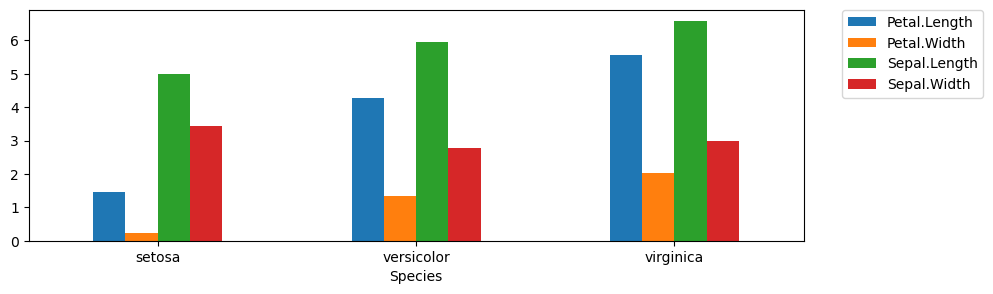

In [72]:
# 범례를 밖으로 : 시각화20page. 판다스60page.
import matplotlib.pyplot as plt
g.plot(kind='bar', figsize=(10,3), rot=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [79]:
iris.pivot_table(index='Species', values='Sepal.Length', aggfunc='count')
iris.groupby('Species')['Sepal.Length'].count()
iris['Species'].value_counts() # 정렬까지

setosa        50
versicolor    50
virginica     50
Name: Species, dtype: int64

In [95]:
# 임의로 각열마다 결측치를 할당(0번째 열은 결측치1 / 1번째열은 결측치2 / 2번째열은 결측치3/ 3번째열은 결측치4)
import numpy as np
import random
# random.sample(range(0,150), 2)
for col in range(iris.shape[1]-1):
    rows = random.sample(range(len(iris)), col+1)
    iris.iloc[rows, col] = np.nan

In [99]:
# 열별 결측치를 제외한 데이터 갯수
iris.groupby('Species').count()
iris.pivot_table(index='Species', aggfunc='count')

,Petal.Length,Petal.Width,Sepal.Length,Sepal.Width
Species,,,,
setosa,49,48,50,50
versicolor,50,48,49,50
virginica,48,50,50,48


### 다중열로 그룹화

In [101]:
iris.head(1)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa


In [109]:
# iris로 다중열 그룹화하기 위해 데이터 추가(num 컬럼)
# iris 행수는 150개 = Species 3그룹, num 6그룹
iris['num'] = np.array([[i]*25 for i in range(6)]).flatten()
iris.iloc[::25]

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species,num
0,5.1,3.5,1.4,0.2,setosa,0
25,5.0,3.0,1.6,0.2,setosa,1
50,7.0,3.2,4.7,1.4,versicolor,2
75,6.6,3.0,4.4,1.4,versicolor,3
100,6.3,3.3,6.0,2.5,virginica,4
125,7.2,3.2,6.0,1.8,virginica,5


In [113]:
# 종별, num별 합계
r = iris.groupby(['Species', 'num']).sum()
r

Sepal.Length  ...  Petal.Width
Species    num                ...             
setosa     0           125.7  ...          6.1
           1           124.6  ...          5.7
versicolor 2           145.1  ...         31.3
           3           146.5  ...         32.7
virginica  4           164.4  ...         51.1
           5           165.0  ...         50.2

[6 rows x 4 columns]

In [115]:
r.loc[['setosa','virginica']] # setosa와 virginica의 합계만

Sepal.Length  ...  Petal.Width
Species   num                ...             
setosa    0           125.7  ...          6.1
          1           124.6  ...          5.7
virginica 4           164.4  ...         51.1
          5           165.0  ...         50.2

[4 rows x 4 columns]

In [116]:
r.loc[[('setosa',0),('virginica',5)]] # num이 0과 5인 합계만

,,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Species,num,,,,
setosa,0,125.7,87.0,35.1,6.1
virginica,5,165.0,72.4,126.1,50.2


In [117]:
# 종별, num별 합계
iris.pivot_table(index=['Species', 'num'])

Petal.Length  ...  Sepal.Width
Species    num                ...             
setosa     0        1.462500  ...     3.480000
           1        1.464000  ...     3.376000
versicolor 2        4.312000  ...     2.776000
           3        4.208000  ...     2.764000
virginica  4        5.640000  ...     2.916667
           5        5.482609  ...     3.016667

[6 rows x 4 columns]

In [119]:
# 종별 기초통계량들
iris.groupby(['Species']).describe().T

Species                setosa  ...  virginica
Sepal.Length count  50.000000  ...  50.000000
             mean    5.006000  ...   6.588000
             std     0.352490  ...   0.635880
             min     4.300000  ...   4.900000
             25%     4.800000  ...   6.225000
             50%     5.000000  ...   6.500000
             75%     5.200000  ...   6.900000
             max     5.800000  ...   7.900000
Sepal.Width  count  50.000000  ...  48.000000
             mean    3.428000  ...   2.966667
             std     0.379064  ...   0.327033
             min     2.300000  ...   2.200000
             25%     3.200000  ...   2.800000
             50%     3.400000  ...   3.000000
             75%     3.675000  ...   3.125000
             max     4.400000  ...   3.800000
Petal.Length count  49.000000  ...  48.000000
             mean    1.463265  ...   5.564583
             std     0.175231  ...   0.555242
             min     1.000000  ...   4.500000
             25%     1.400000  ...   5.100000
             50%     1.500000  ...   5.550000
             75%     1.600000  ...   5.900000
             max     1.900000  ...   6.900000
Petal.Width  count  48.000000  ...  50.000000
             mean    0.245833  ...   2.026000
             std     0.103056  ...   0.274650
             min     0.100000  ...   1.400000
             25%     0.200000  ...   1.800000
             50%     0.200000  ...   2.000000
             75%     0.300000  ...   2.300000
             max     0.600000  ...   2.500000
num          count  50.000000  ...  50.000000
             mean    0.500000  ...   4.500000
             std     0.505076  ...   0.505076
             min     0.000000  ...   4.000000
             25%     0.000000  ...   4.000000
             50%     0.500000  ...   4.500000
             75%     1.000000  ...   5.000000
             max     1.000000  ...   5.000000

[40 rows x 3 columns]